# **Coding Redundancy**

In [ ]:
from collections import Counter
import heapq
import math

# 2x2 grayscale image
image = [
    [100, 100],
    [150, 200]
]

# Step 1: Flatten and count frequencies
pixels = [p for row in image for p in row]
freq = Counter(pixels)
total_symbols = len(pixels)

# Step 2: Fixed-length encoding bits
unique_symbols = len(freq)
fixed_bits_per_symbol = math.ceil(math.log2(unique_symbols))
total_fixed_bits = total_symbols * fixed_bits_per_symbol

# Step 3: Huffman coding
heap = [[wt, [sym, ""]] for sym, wt in freq.items()]
heapq.heapify(heap)
while len(heap) > 1:
    lo = heapq.heappop(heap)
    hi = heapq.heappop(heap)
    for pair in lo[1:]:
        pair[1] = '0' + pair[1]
    for pair in hi[1:]:
        pair[1] = '1' + pair[1]
    heapq.heappush(heap, [lo[0] + hi[0]] + lo[1:] + hi[1:])
huff_dict = dict(sorted(heap[0][1:]))

# Step 4: Huffman encoding length
total_huffman_bits = sum(freq[sym] * len(code) for sym, code in huff_dict.items())

# Step 5: Compute redundancy and saving
avg_fixed = total_fixed_bits / total_symbols
avg_huffman = total_huffman_bits / total_symbols
redundancy = avg_fixed - avg_huffman
saving = (1 - total_huffman_bits / total_fixed_bits) * 100

# Output
print("Huffman Codes:")
for k, v in huff_dict.items():
    print(f"{k}: {v}")

print(f"\nFixed-length bits per symbol: {fixed_bits_per_symbol}")
print(f"Total Fixed-length bits: {total_fixed_bits}")
print(f"Total Huffman bits: {total_huffman_bits}")
print(f"Redundancy: {redundancy:.2f} bits/symbol")
print(f"Code saving: {saving:.2f}%")

Huffman Codes:
100: 0
150: 10
200: 11

Fixed-length bits per symbol: 2
Total Fixed-length bits: 8
Total Huffman bits: 6
Redundancy: 0.50 bits/symbol
Code saving: 25.00%


# **Spatial Redundancy**

In [ ]:
from collections import Counter
import heapq
import math

# Step 1: Original 2x2 grayscale image
image = [
    [100, 100],
    [150, 200]
]

def flatten(img):
    return [p for row in img for p in row]

def huffman_encode(data):
    freq = Counter(data)
    heap = [[wt, [sym, ""]] for sym, wt in freq.items()]
    heapq.heapify(heap)
    while len(heap) > 1:
        lo = heapq.heappop(heap)
        hi = heapq.heappop(heap)
        for pair in lo[1:]:
            pair[1] = '0' + pair[1]
        for pair in hi[1:]:
            pair[1] = '1' + pair[1]
        heapq.heappush(heap, [lo[0] + hi[0]] + lo[1:] + hi[1:])
    huff_dict = dict(heap[0][1:])
    total_bits = sum(freq[sym] * len(huff_dict[sym]) for sym in freq)
    return total_bits, huff_dict, freq

# Step 2: Huffman encode original image
original_pixels = flatten(image)
original_bits, original_codes, original_freq = huffman_encode(original_pixels)

# Step 3: Create difference image (left neighbor predictor)
def get_diff_image(img):
    diff = []
    for row in img:
        row_diff = [row[0]]  # first pixel stays the same
        for i in range(1, len(row)):
            row_diff.append(row[i] - row[i-1])
        diff.append(row_diff)
    return diff

diff_image = get_diff_image(image)
diff_pixels = flatten(diff_image)

# Step 4: Huffman encode difference image
diff_bits, diff_codes, diff_freq = huffman_encode(diff_pixels)

# Step 5: Compute spatial redundancy saving
saving = (1 - diff_bits / original_bits) * 100

# Output
print("Original Image Huffman Coding:")
for k, v in original_codes.items():
    print(f"{k}: {v}")
print(f"Total bits: {original_bits}\n")

print("Difference Image Huffman Coding:")
for k, v in diff_codes.items():
    print(f"{k}: {v}")
print(f"Total bits: {diff_bits}\n")

print(f"Spatial Redundancy Saving: {saving:.2f}%")

Original Image Huffman Coding:
100: 0
150: 10
200: 11
Total bits: 6

Difference Image Huffman Coding:
0: 00
50: 01
100: 10
150: 11
Total bits: 8

Spatial Redundancy Saving: -33.33%


# **Irrelavent Redundancy**

In [ ]:
import numpy as np
from scipy.fftpack import dct, idct
from collections import Counter
import heapq

# 1. Original 2x2 grayscale image
image = np.array([
    [100, 100],
    [150, 200]
], dtype=np.float32)

# Flattened original image
original_pixels = image.flatten().astype(int).tolist()

# 2. Huffman on original (no psychovisual reduction)
def huffman_encode(data):
    freq = Counter(data)
    heap = [[wt, [sym, ""]] for sym, wt in freq.items()]
    heapq.heapify(heap)
    while len(heap) > 1:
        lo = heapq.heappop(heap)
        hi = heapq.heappop(heap)
        for pair in lo[1:]: pair[1] = '0' + pair[1]
        for pair in hi[1:]: pair[1] = '1' + pair[1]
        heapq.heappush(heap, [lo[0]+hi[0]] + lo[1:] + hi[1:])
    huff_dict = dict(heap[0][1:])
    total_bits = sum(freq[sym] * len(huff_dict[sym]) for sym in freq)
    return total_bits, huff_dict, freq

original_bits, original_codes, _ = huffman_encode(original_pixels)

# 3. Apply DCT (2D)
def dct2(a):
    return dct(dct(a.T, norm='ortho').T, norm='ortho')

dct_image = dct2(image)

# 4. Quantize DCT (simulate psychovisual loss)
Q = 10  # Quantization step
quant_dct = np.round(dct_image / Q).astype(int)
quant_dct_flat = quant_dct.flatten().tolist()

# 5. Huffman encode quantized DCT
quant_bits, quant_codes, _ = huffman_encode(quant_dct_flat)

# 6. Calculate savings
saving = (1 - quant_bits / original_bits) * 100

# Print Results
print("Original Image Huffman Codes:")
for k, v in original_codes.items():
    print(f"{k}: {v}")
print(f"Total bits (original): {original_bits}\n")

print("Quantized DCT Huffman Codes:")
for k, v in quant_codes.items():
    print(f"{k}: {v}")
print(f"Total bits (quantized DCT): {quant_bits}\n")

print(f"Irrelevant Redundancy Saving: {saving:.2f}%")

Original Image Huffman Codes:
100: 0
150: 10
200: 11
Total bits (original): 6

Quantized DCT Huffman Codes:
-8: 00
-3: 01
2: 10
28: 11
Total bits (quantized DCT): 8

Irrelevant Redundancy Saving: -33.33%


# **Calculation of Entropy of an image**

In [ ]:
import numpy as np
from collections import Counter
import math

def calculate_entropy(image):
    # Flatten the image to 1D
    pixels = image.flatten().tolist()

    # Count frequency of each pixel value
    freq = Counter(pixels)
    total = len(pixels)

    # Calculate entropy
    entropy = -sum((count/total) * math.log2(count/total) for count in freq.values())
    return entropy

# Example: 2x2 grayscale image
image = np.array([
    [100, 100],
    [150, 200]
], dtype=np.uint8)

entropy = calculate_entropy(image)
print(f"Entropy of the image: {entropy:.4f} bits per pixel")

Entropy of the image: 1.5000 bits per pixel


# **Calculation of fidelity of an image**

In [ ]:
import numpy as np
import math

def calculate_mse_psnr(original, compressed):
    # Ensure input arrays are float type
    original = original.astype(np.float32)
    compressed = compressed.astype(np.float32)

    mse = np.mean((original - compressed) ** 2)

    if mse == 0:
        psnr = float('inf')  # No error means infinite PSNR
    else:
        max_pixel = 255.0
        psnr = 10 * math.log10((max_pixel ** 2) / mse)

    return mse, psnr

# Example: original and compressed 2x2 images
original_image = np.array([
    [100, 100],
    [150, 200]
], dtype=np.uint8)

compressed_image = np.array([
    [102, 98],
    [148, 205]
], dtype=np.uint8)

mse, psnr = calculate_mse_psnr(original_image, compressed_image)

print(f"MSE: {mse:.4f}")
print(f"PSNR: {psnr:.2f} dB")

MSE: 9.2500
PSNR: 38.47 dB


# **Unary Encoding**

In [ ]:
def unary_encode(n):
    return '1' * n + '0'

# Test
for i in range(5):
    print(f"{i}: {unary_encode(i)}")

0: 0
1: 10
2: 110
3: 1110
4: 11110


# **Golomb Encoding**

In [ ]:
import math

def unary_encode(n):
    return '1' * n + '0'

def truncated_binary_encode(r, m):
    b = math.ceil(math.log2(m))
    threshold = (1 << b) - m
    if r < threshold:
        return format(r, f'0{b - 1}b')
    else:
        r += threshold
        return format(r, f'0{b}b')

def golomb_encode(n, m):
    q = n // m
    r = n % m
    return unary_encode(q) + truncated_binary_encode(r, m)

# Test
m = 3
for n in range(10):
    print(f"{n}: {golomb_encode(n, m)}")

0: 00
1: 010
2: 011
3: 100
4: 1010
5: 1011
6: 1100
7: 11010
8: 11011
9: 11100


# **Arithmetic Coding**

In [ ]:
import math

class ArithmeticCoder:
    def __init__(self, symbol_probs):
        """Initialize with symbol probabilities.
        Args:
            symbol_probs (dict): {'A': 0.5, 'B': 0.3, 'C': 0.2}
        """
        self.symbol_probs = symbol_probs
        self._validate_probabilities()
        self._build_cumulative_probs()

    def _validate_probabilities(self):
        total = sum(self.symbol_probs.values())
        if not math.isclose(total, 1.0, rel_tol=1e-5):
            raise ValueError("Probabilities must sum to 1.")

    def _build_cumulative_probs(self):
        self.cumulative_probs = {}
        cumulative = 0.0
        for symbol, prob in self.symbol_probs.items():
            self.cumulative_probs[symbol] = (cumulative, cumulative + prob)
            cumulative += prob

    def encode(self, sequence):
        """Encode a sequence into a fractional number."""
        low, high = 0.0, 1.0
        for symbol in sequence:
            symbol_low, symbol_high = self.cumulative_probs[symbol]
            range_size = high - low
            high = low + range_size * symbol_high
            low = low + range_size * symbol_low
        return (low + high) / 2  # Return midpoint

    def decode(self, encoded_number, length):
        """Decode an encoded number back to the original sequence."""
        sequence = []
        low, high = 0.0, 1.0
        for _ in range(length):
            # Find the symbol corresponding to the current range
            for symbol, (symbol_low, symbol_high) in self.cumulative_probs.items():
                current_range = high - low
                current_high = low + current_range * symbol_high
                current_low = low + current_range * symbol_low
                if current_low <= encoded_number < current_high:
                    sequence.append(symbol)
                    low, high = current_low, current_high
                    break
        return sequence

# Example Usage (Image Pixel Compression)
if __name__ == "__main__":
    # Example: Grayscale pixel values (simplified)
    symbol_probs = {
        '0': 0.1,  # Dark pixel
        '128': 0.6,  # Mid-gray
        '255': 0.3,  # Bright pixel
    }

    coder = ArithmeticCoder(symbol_probs)

    # Simulate an image row (sequence of pixel values)
    original_sequence = ['128', '128', '0', '255', '128']
    print("Original Sequence:", original_sequence)

    # Encode
    encoded_value = coder.encode(original_sequence)
    print(f"Encoded Value: {encoded_value:.10f}")

    # Decode
    decoded_sequence = coder.decode(encoded_value, len(original_sequence))
    print("Decoded Sequence:", decoded_sequence)

    # Check if decoded matches original
    assert decoded_sequence == original_sequence, "Decoding failed!"

Original Sequence: ['128', '128', '0', '255', '128']
Encoded Value: 0.1895200000
Decoded Sequence: ['128', '128', '0', '255', '128']


# **Lempel-Ziv-Welch (LZW) Coding**

In [ ]:
def lzw_compress(data):
    """Compress data using LZW algorithm."""
    # Initialize dictionary with all possible 1-byte sequences (0-255)
    dictionary = {chr(i): i for i in range(256)}
    next_code = 256  # Next available code for new sequences
    compressed = []
    current_sequence = ""

    for symbol in data:
        combined_sequence = current_sequence + symbol
        if combined_sequence in dictionary:
            current_sequence = combined_sequence
        else:
            # Output the code for current_sequence
            compressed.append(dictionary[current_sequence])
            # Add new sequence to dictionary
            dictionary[combined_sequence] = next_code
            next_code += 1
            current_sequence = symbol  # Reset to current symbol

    if current_sequence:  # Handle remaining sequence
        compressed.append(dictionary[current_sequence])

    return compressed

def lzw_decompress(compressed):
    """Decompress LZW-encoded data."""
    # Rebuild the dictionary (inverse of compression)
    dictionary = {i: chr(i) for i in range(256)}
    next_code = 256
    decompressed = []
    previous_sequence = chr(compressed[0])
    decompressed.append(previous_sequence)

    for code in compressed[1:]:
        if code in dictionary:
            current_sequence = dictionary[code]
        elif code == next_code:  # Handle edge case (GIF compatibility)
            current_sequence = previous_sequence + previous_sequence[0]
        else:
            raise ValueError("Invalid LZW code detected.")

        decompressed.append(current_sequence)
        # Add new sequence to dictionary
        dictionary[next_code] = previous_sequence + current_sequence[0]
        next_code += 1
        previous_sequence = current_sequence

    return ''.join(decompressed)

# Example Usage (Text Compression)
if __name__ == "__main__":
    # Example 1: Text compression
    original_text = "TOBEORNOTTOBEORTOBEORNOT"
    print("Original:", original_text)

    compressed = lzw_compress(original_text)
    print("Compressed Codes:", compressed)

    decompressed = lzw_decompress(compressed)
    print("Decompressed:", decompressed)
    assert decompressed == original_text, "Decompression failed!"

    # Example 2: Simulate image pixel data (e.g., "R G B R G B...")
    pixel_data = "RGBRGBRGBRGB"
    print("\nOriginal Pixels:", pixel_data)

    compressed_pixels = lzw_compress(pixel_data)
    print("Compressed Pixel Codes:", compressed_pixels)

    decompressed_pixels = lzw_decompress(compressed_pixels)
    print("Decompressed Pixels:", decompressed_pixels)
    assert decompressed_pixels == pixel_data, "Decompression failed!"

Original: TOBEORNOTTOBEORTOBEORNOT
Compressed Codes: [84, 79, 66, 69, 79, 82, 78, 79, 84, 256, 258, 260, 265, 259, 261, 263]
Decompressed: TOBEORNOTTOBEORTOBEORNOT

Original Pixels: RGBRGBRGBRGB
Compressed Pixel Codes: [82, 71, 66, 256, 258, 257, 259]
Decompressed Pixels: RGBRGBRGBRGB


# **Run Length Coding (RLC)**

Basic RLE (For Strings or Grayscale Pixels)

In [ ]:
def rle_encode(data):
    """Encode data using Run-Length Encoding."""
    encoded = []
    count = 1
    for i in range(1, len(data)):
        if data[i] == data[i - 1]:
            count += 1
        else:
            encoded.append(f"{count}{data[i - 1]}")
            count = 1
    encoded.append(f"{count}{data[-1]}")  # Add last run
    return ''.join(encoded)

def rle_decode(encoded):
    """Decode RLE-encoded data."""
    decoded = []
    i = 0
    while i < len(encoded):
        # Extract count (multi-digit support)
        count_str = ''
        while i < len(encoded) and encoded[i].isdigit():
            count_str += encoded[i]
            i += 1
        if not count_str:
            raise ValueError("Invalid RLE format")
        count = int(count_str)
        # Get symbol (assumes 1 char per symbol; modify for binary)
        symbol = encoded[i]
        decoded.append(symbol * count)
        i += 1
    return ''.join(decoded)

# Example Usage (Text/Strings)
original_text = "AAAABBBCCDAA"
print("Original:", original_text)
encoded = rle_encode(original_text)
print("Encoded:", encoded)  # Output: "4A3B2C1D2A"
decoded = rle_decode(encoded)
print("Decoded:", decoded)
assert decoded == original_text, "Decoding failed!"

Original: AAAABBBCCDAA
Encoded: 4A3B2C1D2A
Decoded: AAAABBBCCDAA


RLE for Binary Image Data (0s and 1s)

In [ ]:
def rle_encode_binary(pixels):
    """Encode binary pixel data (0=black, 1=white)."""
    encoded = []
    current = pixels[0]
    count = 1
    for pixel in pixels[1:]:
        if pixel == current:
            count += 1
        else:
            encoded.append(str(count))
            current = pixel
            count = 1
    encoded.append(str(count))
    return ' '.join(encoded)  # Space-separated counts

def rle_decode_binary(encoded):
    """Decode binary RLE data."""
    decoded = []
    counts = list(map(int, encoded.split()))
    color = 0  # Start with 0 (black)
    for count in counts:
        decoded.extend([color] * count)
        color ^= 1  # Toggle between 0 and 1
    return decoded

# Example Usage (Binary Image)
binary_pixels = [0, 0, 0, 1, 1, 0, 0, 1, 1, 1]
print("\nOriginal Binary:", binary_pixels)
encoded_binary = rle_encode_binary(binary_pixels)
print("Encoded Binary:", encoded_binary)  # Output: "3 2 2 3"
decoded_binary = rle_decode_binary(encoded_binary)
print("Decoded Binary:", decoded_binary)
assert decoded_binary == binary_pixels, "Decoding failed!"


Original Binary: [0, 0, 0, 1, 1, 0, 0, 1, 1, 1]
Encoded Binary: 3 2 2 3
Decoded Binary: [0, 0, 0, 1, 1, 0, 0, 1, 1, 1]


# **RLE for Grayscale/RGB Images**

In [ ]:
def rle_encode_pixels(pixels):
    """Encode grayscale/RGB pixels."""
    encoded = []
    current = pixels[0]
    count = 1
    for pixel in pixels[1:]:
        if pixel == current:
            count += 1
        else:
            encoded.append((count, current))
            current = pixel
            count = 1
    encoded.append((count, current))
    return encoded

def rle_decode_pixels(encoded):
    """Decode grayscale/RGB RLE data."""
    decoded = []
    for count, pixel in encoded:
        decoded.extend([pixel] * count)
    return decoded

# Example Usage (Grayscale Image)
grayscale_pixels = [100, 100, 100, 200, 200, 100, 100]
print("\nOriginal Grayscale:", grayscale_pixels)
encoded_grayscale = rle_encode_pixels(grayscale_pixels)
print("Encoded Grayscale:", encoded_grayscale)  # Output: [(3, 100), (2, 200), (2, 100)]
decoded_grayscale = rle_decode_pixels(encoded_grayscale)
print("Decoded Grayscale:", decoded_grayscale)
assert decoded_grayscale == grayscale_pixels, "Decoding failed!"


Original Grayscale: [100, 100, 100, 200, 200, 100, 100]
Encoded Grayscale: [(3, 100), (2, 200), (2, 100)]
Decoded Grayscale: [100, 100, 100, 200, 200, 100, 100]


# **Bit Plane Coding**

**Basic Bit Plane Slicing (Grayscale Images)**

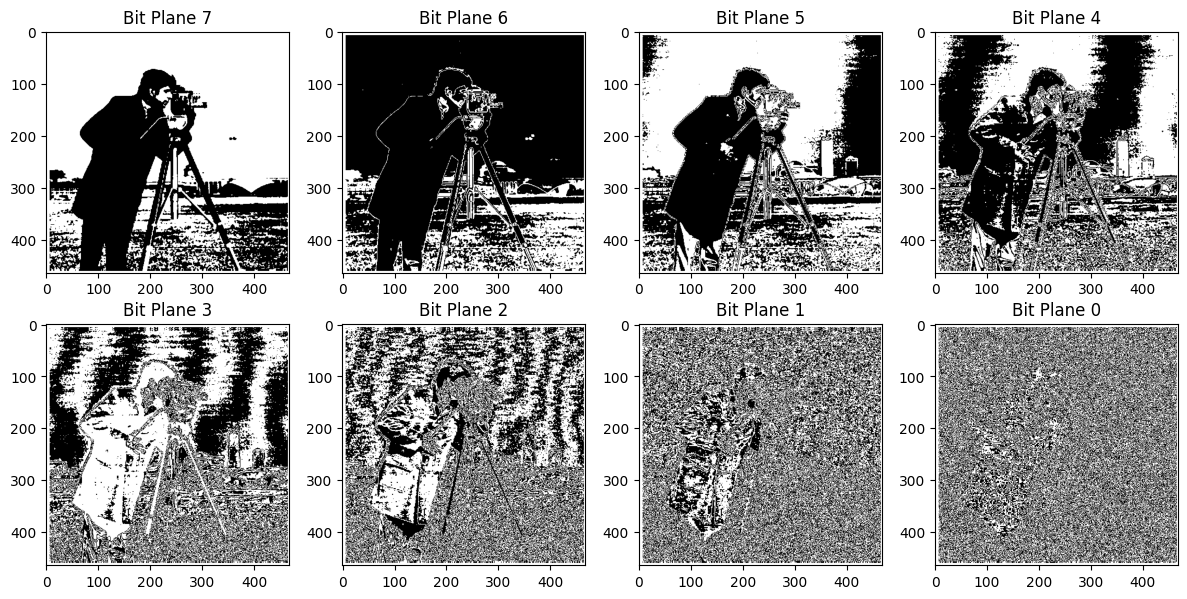

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def bit_plane_slice(img):
    """Extract all 8 bit planes from a grayscale image"""
    planes = []
    for i in range(8):
        plane = (img >> i) & 1  # Extract ith bit
        planes.append(plane)
    return planes

# Load image
img = cv2.imread('thr.png', cv2.IMREAD_GRAYSCALE)

# Get bit planes
bit_planes = bit_plane_slice(img)

# Display planes
plt.figure(figsize=(12, 6))
for i, plane in enumerate(bit_planes[::-1]):  # Show MSB first
    plt.subplot(2, 4, i+1)
    plt.imshow(plane * 255, cmap='gray')
    plt.title(f'Bit Plane {7-i}')
plt.tight_layout()
plt.show()

**Selective Bit Plane Extraction**

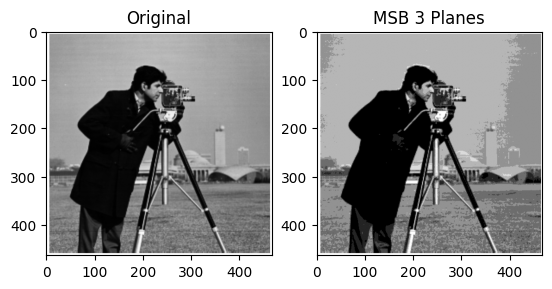

In [3]:
def extract_specific_planes(img, keep_planes=[7,6,5]):
    """Reconstruct image using only specified bit planes"""
    reconstructed = np.zeros_like(img)
    for i in keep_planes:
        reconstructed += ((img >> i) & 1) << i
    return reconstructed

# Keep only 3 most significant bits
reconstructed = extract_specific_planes(img, keep_planes=[7,6,5])

# Compare
plt.subplot(121); plt.imshow(img, cmap='gray'); plt.title('Original')
plt.subplot(122); plt.imshow(reconstructed, cmap='gray'); plt.title('MSB 3 Planes')
plt.show()